In [192]:
import os

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

os.makedirs("outputs", exist_ok=True)

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


# PyTorch Tensors

## Tensor Question 1
Create the following tensors and, for each one, print its value, shape, dtype, and device. 
What device are these tensors on right now? If you were running a training loop on the GPU, why would it matter that your model weights and your input tensors are on the same device?

In [193]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

print("a:")
print(a)
print(a.shape)
print(a.dtype)
print(a.device)

print("b:")
print(b)
print(b.shape)
print(b.dtype)
print(b.device)

print("c:")
print(c)
print(c.shape)
print(c.dtype)
print(c.device)


a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
torch.float32
cpu
b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
torch.Size([2, 3])
torch.float32
cpu
c:
tensor([1., 1., 1., 1.])
torch.Size([4])
torch.float32
cpu


All tensors (a, b, c) are currently on the CPU by default (device='cpu'),since no GPU device was specified when creating them. When training on a GPU, it is important that both the model weights and input tensors are on the same device. Additionally, keeping everything on the same device avoids unnecessary data transfers between CPU and GPU, which can significantly slow down computation.

## Tensor Question 2

* Compute and print the element-wise square root using torch.sqrt().
* Compute and print the sum using .sum().
* Compute and print the mean using .mean().
* Find and print the index of the maximum value using .argmax().

.argmax() appears in nearly every inference example you'll encounter. In the context of a classifier that outputs scores for 1,000 classes, what does .argmax() give you?


In [194]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
sqrtx = torch.sqrt(x)
print("Square root:", sqrtx)
print("Sum:", x.sum())
print("Mean:", x.mean())
print("Argmax (index of max):", x.argmax())

Square root: tensor([1., 2., 3., 4., 5.])
Sum: tensor(55.)
Mean: tensor(11.)
Argmax (index of max): tensor(4)


**.argmax()** returns the index of the class with the highest score. In a classifier that outputs scores for 1,000 classes, the index of max corresponds to the model’s predicted class

## Tensor Question 3
Move tensor a from Question 1 to the GPU, then bring it back to CPU and convert it to a NumPy array. 
Why does PyTorch require .cpu() before you can call .numpy()? What does this tell you about where NumPy arrays live?


In [195]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


PyTorch requires calling .cpu() before .numpy() because NumPy arrays can only exist in CPU memory (RAM), not on the GPU. If a tensor is on the GPU, it must first be transferred back to the CPU so NumPy can access and represent its data. This shows that NumPy operates only on CPU-based data, while PyTorch can handle both CPU and GPU tensors.

## Tensor Question 4
1. Reshape t to (4, 6) and print the shape.
2. Reshape t to (2, 3, 4) and print the shape.
3. Take your result from step 1 and add a new dimension at position 0. Print the new shape.

A single image tensor typically has shape (channels, height, width). Neural networks expect batches with shape (batch_size, channels, height, width). What operation accomplishes this when you are processing one image at a time, and why does it matter?

In [196]:
t = torch.arange(24).float()
a = t.reshape(4,6)
print(a)

b = t.reshape(2,3,4)
print(b)

c = a.unsqueeze(0)
print(c)

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.]])
tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])
tensor([[[ 0.,  1.,  2.,  3.,  4.,  5.],
         [ 6.,  7.,  8.,  9., 10., 11.],
         [12., 13., 14., 15., 16., 17.],
         [18., 19., 20., 21., 22., 23.]]])


.unsqueeze(0) adds a new "batch" dimension at the start. This is important because even if we only have one image, the model still expects inputs in batches. So we add this extra dimension to make the shape look like: (batch_size, channels, height, width). This helps the model process data in a consistent way, whether it is one image or many images at the same time.

## Tensor Question 5
Compare PyTorch and NumPy for matrix multiplication. 

1. Compute the matrix product using NumPy and print the result.
2. Compute the same product using PyTorch and print the result.
3. Confirm the outputs match.

At a high level, what role does matrix multiplication play as data passes through a single layer of a neural network?

In [197]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

result_np = np.matmul(np_a, np_b)
print("NumPy result:\n", result_np)

result_t = torch.matmul(t_a, t_b)
print("PyTorch result:\n", result_t)

print("Match?", np.allclose(result_np, result_t.numpy()))

NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 tensor([[19., 22.],
        [43., 50.]])
Match? True


Matrix multiplication is how a neural network layer combines inputs with its weights. Each layer takes the input data and multiplies it by a weight matrix to produce new values (features), which are then passed to the next layer. This is the main way the network learns patterns from data.

# Pretrained Models

## Model Question 1
Load ResNet18 with pretrained weights and count its parameters.ResNet18 has roughly 11 million parameters. Training it from scratch required approximately 1.2 million labeled ImageNet images and days of multi-GPU compute. What does that tell you about the practical value of starting from pretrained weights when you're on a deadline or a budget?

In [198]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,689,512
Trainable parameters: 11,689,512


Starting from pretrained weights saves a huge amount of time and resources. Instead of training millions of parameters from scratch (which needs a lot of data and expensive compute), we can reuse a model that has already learned useful features. This lets us get good results faster, even with less data and limited hardware, which is very helpful when working under a deadline or budget.

## Model Question 2
Print the full model architecture by running print(model).
1. What is the name of the final layer in ResNet18, and what is its output size? (This number is the total count of ImageNet categories the model can predict.)
2. Can you identify the blocks named layer1 through layer4? These are the "deep" part of the network — the feature extractor. In plain terms, what does it mean for a network to be "deep"?

In [199]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

1. The final layer is named "fc" (fully connected layer). Its output size is 1000, which means the model can predict 1000 different ImageNet categories.
2. The blocks layer1 through layer4 are the main feature extractor parts of the network. They process the image step by step and learn more complex patterns at each stage. A "deep" network means it has many layers stacked together. Each layer learns something new, starting from simple features (like edges) to more complex features (like shapes or objects).

## Model Question 3
Before running inference, move the model to the GPU and set it to evaluation mode. 
1. What does .to(device) do, and why does it need to match the device your input tensors will be on?
2. What does model.eval() change about the model's behavior? Name at least one layer type that behaves differently in training mode vs. evaluation mode.

In [200]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


**model.to(device)**: This moves all model weights to the same device (e.g., 'cuda' for GPU). It must match the device of the input tensors, otherwise PyTorch will raise an error because it cannot perform operations across different devices.

**model.eval():** This switches the model to inference mode. Some layers behave differently during training vs. evaluation.
Dropout is a layer that behaves differently in training and evaluation. In training, it randomly turns off some neurons to help the model learn better. In evaluation, it uses all neurons to give the best and most stable prediction. A simple real-life example is like practicing for a test without using some tools, but during the actual test, we will use all the tools to perform our best.


## Model Question 4
TorchVision model weights include the exact preprocessing pipeline the model was trained with. Add a comment describing in plain English what each step does and why it matters.
1. What does the resize/crop step accomplish?
2. What does ToTensor() do to the pixel value range?
3. What is normalization doing, and why does it use ImageNet's specific mean and standard deviation values rather than, say, mean=0.5, std=0.5?


In [201]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


1. The image is first resized and then center-cropped to 224x224 pixels. This makes sure every image has the same size the model expects, so it can process inputs consistently
2. **ToTensor()**: This converts the image from pixel values (0–255) into a tensor with values between 0.0 and 1.0. This makes the data easier for the model to work with.
3.  Normalization: This adjusts the image values using the ImageNet mean and standard deviation. It helps center and scale the data so the model sees inputs similar to what it was trained on.
4.  The model was trained on ImageNet data using these exact values,so using the same mean and std ensures the input matches what the model expects. Using different values (like 0.5, 0.5) could reduce accuracy.

# Running Inference

In [202]:
from pathlib import Path
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG"]:
        img_files.extend(class_dir.glob(ext))

    if len(img_files) == 0:
        raise ValueError(f"No images found in {class_dir}")

    img_path = random.choice(img_files)
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Inference Question 1
Write a function that runs inference on a single PIL image and returns the top-5 predicted class names and their probabilities. The function signature and steps are given below — fill in the implementation. Test it on one mountain image. Does the top prediction make sense? Remember that the model was trained on ImageNet's 1,000 categories, which include things like "alp", "valley", and "lakeside" rather than simply "mountain". Do any of the top-5 labels map onto what you'd describe as a mountain scene?

In [203]:
import torch.nn.functional as F

def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: Convert raw scores (logits) to probabilities
    probs = F.softmax(output[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    top_probs, top_indices = torch.topk(probs, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    top5 = [
        (class_labels[idx.item()], top_probs[i].item())
        for i, idx in enumerate(top_indices)
    ]

    return top5
    pass

In [204]:
img, img_name = load_sample_image("mountain/")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


The model may not predict “mountain” directly, but it often predicts related labels like “alp” or “valley.” These still match the image, so the prediction usually makes sense even if the exact label is missing.

## Inference Question 2
Run inference on one image from each of the six scene classes. For each, print the top-3 predictions. Which classes does the model seem most confident about (high top-1 probability)? Which does it seem least confident about? Is there a pattern?

In [205]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


The model is most confident in the mountain image because it has the highest top-1 probability (around 0.59). It also shows fairly strong confidence on glacier and buildings, where the top predictions have clear leading probabilities. The model is least confident on sea and street, where the top probabilities are much lower and spread across multiple classes. This means the model is less sure about these images. A clear pattern is that the model is more confident when the scene has strong, distinctive features (like snow or mountains) and less confident when the scene is more complex or mixed (like sea or street).

## Inference Question 3
The raw output of the model before softmax is called logits — unconstrained scores that can be any real number. After softmax they become probabilities that sum to 1. Observe the difference. Why do neural networks output logits internally rather than probabilities? In a production pipeline that needs to filter out low-confidence predictions, which representation would you work with — logits or probabilities — and why?

In [206]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


Neural networks use logits because they are raw scores and are more stable for training. If we convert them to probabilities too early, the math becomes less stable, and learning can become harder. That is why loss functions usually work directly with logits. In real systems, logits are better for internal use, like ranking or setting thresholds, because they are stable and keep the original model output. Probabilities are better for people to read and understand, so we usually convert logits to probabilities only at the end, when showing results.

## Inference Question 4

Create a visualization that shows an image alongside a horizontal bar chart of its top-5 predictions. Use plt.subplots(1, 2) with one panel for the image and one for the bar chart. Save it to outputs/warmup_inference_viz.png.
You have all the pieces — img, preds, and plt — from the previous questions. Write the visualization yourself.
How would you adapt this kind of visualization for a dashboard that a non-technical team member needs to review flagged predictions? What threshold on the top-1 probability might you use to decide when a prediction is "confident enough" to act on?

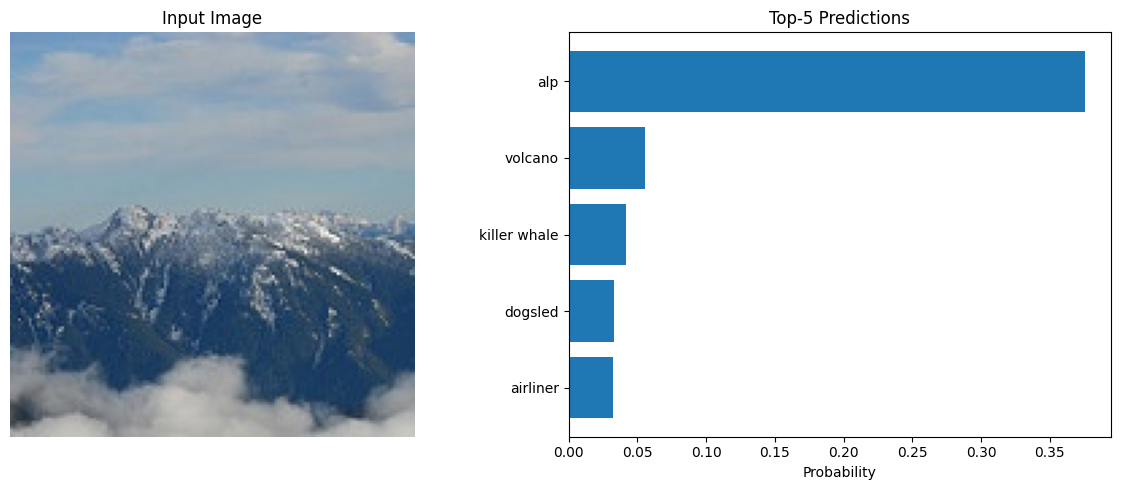

In [ ]:
import matplotlib.pyplot as plt
import os

def visualize_inference(image, preds, save_path="outputs/warmup_inference_viz.png"):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    class_names = [p[0] for p in preds]
    probs = [p[1] for p in preds]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Image panel
    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title("Input Image")

    # Bar chart panel
    axes[1].barh(class_names[::-1], probs[::-1])
    axes[1].set_title("Top-5 Predictions")
    axes[1].set_xlabel("Probability")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

img, _ = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

visualize_inference(img, preds)

A simple dashboard should show the image and top predictions clearly. If the top probability is above about 0.70, the prediction is usually reliable, while lower values may need human review.